In [1]:
import pandas as pd
import seaborn as sns
df = sns.load_dataset("titanic")
print("Data shape:", df.shape)
print(df.head())


Data shape: (891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [2]:
#Data Cleaning & Preprocessing


df['age'].fillna(df['age'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

df.drop_duplicates(inplace=True)

df = pd.get_dummies(df, columns=['sex','class','embarked'], drop_first=True)

df['family_size'] = df['sibsp'] + df['parch']
print(df.head())


   survived  pclass   age  sibsp  parch     fare    who  adult_male deck  \
0         0       3  22.0      1      0   7.2500    man        True  NaN   
1         1       1  38.0      1      0  71.2833  woman       False    C   
2         1       3  26.0      0      0   7.9250  woman       False  NaN   
3         1       1  35.0      1      0  53.1000  woman       False    C   
4         0       3  35.0      0      0   8.0500    man        True  NaN   

   embark_town alive  alone  sex_male  class_Second  class_Third  embarked_Q  \
0  Southampton    no  False      True         False         True       False   
1    Cherbourg   yes  False     False         False        False       False   
2  Southampton   yes   True     False         False         True       False   
3  Southampton   yes  False     False         False        False       False   
4  Southampton    no   True      True         False         True       False   

   embarked_S  family_size  
0        True            1  
1   

/tmp/ipykernel_4158/3997486657.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipykernel_4158/3997486657.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

## Data Exploration

In [3]:
print(df.info())
print("\nMissing values after cleaning:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 781 entries, 0 to 890
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   survived      781 non-null    int64   
 1   pclass        781 non-null    int64   
 2   age           781 non-null    float64 
 3   sibsp         781 non-null    int64   
 4   parch         781 non-null    int64   
 5   fare          781 non-null    float64 
 6   who           781 non-null    object  
 7   adult_male    781 non-null    bool    
 8   deck          202 non-null    category
 9   embark_town   779 non-null    object  
 10  alive         781 non-null    object  
 11  alone         781 non-null    bool    
 12  sex_male      781 non-null    bool    
 13  class_Second  781 non-null    bool    
 14  class_Third   781 non-null    bool    
 15  embarked_Q    781 non-null    bool    
 16  embarked_S    781 non-null    bool    
 17  family_size   781 non-null    int64   
dtypes: bool(7), cat

In [6]:
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

print("Missing values after further cleaning:")
print(df.isnull().sum())

Missing values after further cleaning:
survived        0
pclass          0
age             0
sibsp           0
parch           0
fare            0
who             0
adult_male      0
embark_town     0
alive           0
alone           0
sex_male        0
class_Second    0
class_Third     0
embarked_Q      0
embarked_S      0
family_size     0
dtype: int64


## Data Visualization

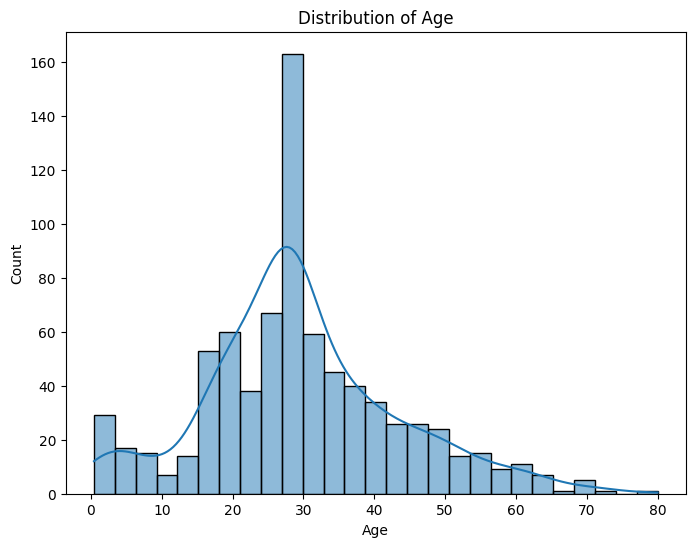

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.histplot(df['age'], kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

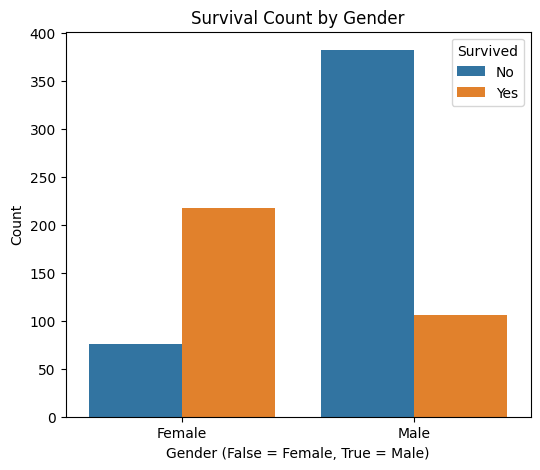

In [8]:
plt.figure(figsize=(6, 5))
sns.countplot(x='sex_male', hue='survived', data=df)
plt.title('Survival Count by Gender')
plt.xlabel('Gender (False = Female, True = Male)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Female', 'Male'])
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

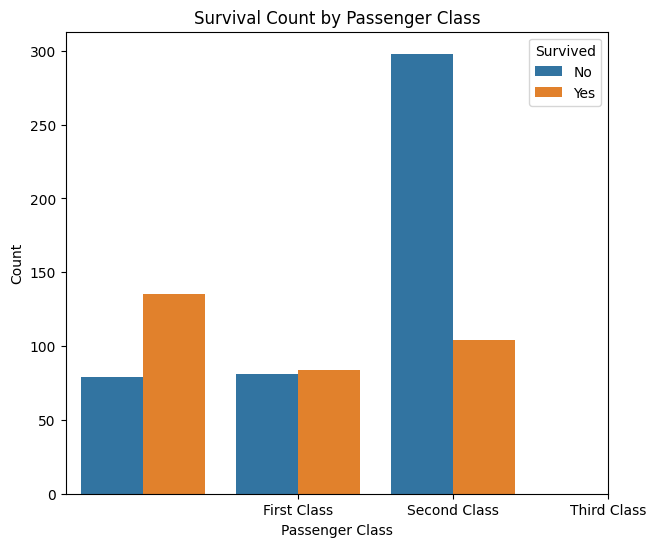

In [9]:
plt.figure(figsize=(7, 6))
sns.countplot(x='pclass', hue='survived', data=df)
plt.title('Survival Count by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.xticks(ticks=[1, 2, 3], labels=['First Class', 'Second Class', 'Third Class'])
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

## Data Preparation for Modeling

In [10]:
# Drop irrelevant columns for modeling
df_model = df.drop(['who', 'embark_town', 'alive'], axis=1)

# Define features (X) and target (y)
X = df_model.drop('survived', axis=1)
y = df_model['survived']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nFirst 5 rows of features (X):")
print(X.head())
print("\nFirst 5 values of target (y):")
print(y.head())

Features (X) shape: (781, 13)
Target (y) shape: (781,)

First 5 rows of features (X):
   pclass   age  sibsp  parch     fare  adult_male  alone  sex_male  \
0       3  22.0      1      0   7.2500        True  False      True   
1       1  38.0      1      0  71.2833       False  False     False   
2       3  26.0      0      0   7.9250       False   True     False   
3       1  35.0      1      0  53.1000       False  False     False   
4       3  35.0      0      0   8.0500        True   True      True   

   class_Second  class_Third  embarked_Q  embarked_S  family_size  
0         False         True       False        True            1  
1         False        False       False       False            1  
2         False         True       False        True            0  
3         False        False       False        True            1  
4         False         True       False        True            0  

First 5 values of target (y):
0    0
1    1
2    1
3    1
4    0
Name: survive

## Model Training

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (624, 13)
X_test shape: (157, 13)
y_train shape: (624,)
y_test shape: (157,)


In [12]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets and handles L1/L2 penalties

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print(f"Model Precision: {precision:.4f}")
print(f"Model Recall: {recall:.4f}")
print(f"Model F1-Score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.7962
Model Precision: 0.8103
Model Recall: 0.6912
Model F1-Score: 0.7460

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.88      0.83        89
           1       0.81      0.69      0.75        68

    accuracy                           0.80       157
   macro avg       0.80      0.78      0.79       157
weighted avg       0.80      0.80      0.79       157



In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Convert categorical columns into numbers
df = pd.get_dummies(df, drop_first=True)

# Define features and target
X = df.drop(columns=['survived'])
y = df['survived']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# Predict values
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 1.0
Precision: 1.0
Recall: 1.0
Confusion Matrix:
 [[89  0]
 [ 0 68]]
